# Chapitre 6 - Manipulation de données avec Pandas

**[Pandas](https://pandas.pydata.org/) est une bibliothèque Python essentielle pour la manipulation et l'analyse de données**. Elle permet de travailler avec des tableaux à deux dimensions, appelés DataFrames, où chaque ligne représente un enregistrement et chaque colonne un champ. Pandas est particulièrement utile pour nettoyer, transformer et analyser des données structurées.

Pandas travaille avec un objet de base: le ``DataFrame``. Un DataFrame est une structure de données bidimensionnelle, similaire à une feuille de calcul ou une table SQL. Il est composé de lignes et de colonnes, où chaque colonne peut contenir des types de données différents (entiers, flottants, chaînes de caractères, etc.).

Il est important de noter que Pandas est construit sur NumPy, ce qui signifie qu'il utilise des **tableaux NumPy** sous le capot pour stocker les données. Cela permet à Pandas d'être **très performant pour les opérations** sur de grandes quantités de données.

### 1. Création d'un DataFrame

Importez la bibliothèque:
```python
import pandas as pd
```
On notera que l'alias `pd` est couramment utilisé pour simplifier l'appel aux fonctions de la bibliothèque.

Vous pouvez créer un DataFrame à partir de diverses sources de données telles que des fichiers CSV, Excel, ou JSON.

##### 1.1 À partir d'un dictionnaire

Vous pouvez créer un DataFrame à partir d'un dictionnaire Python où les clés sont les noms des colonnes et les valeurs sont les données.

```python
data = {
    'Nom': ['Alice', 'Bob', 'Charlie'],
    'Âge': [25, 30, 35],
    'Ville': ['Paris', 'Lyon', 'Marseille']
}
df = pd.DataFrame(data)
print(df)
```

##### 1.2 À partir d'un fichier CSV
Vous pouvez également créer un DataFrame à partir d'un fichier CSV en utilisant la fonction `read_csv()`.

```python
df = pd.read_csv('chemin/vers/fichier.csv')
print(df)
```

##### 1.3 Ou encore à partir d'un fichier json
```python
df = pd.read_json('chemin/vers/fichier.json')
print(df)
```

Pandas offre ensuite des méthodes de base pour explorer les données d'un DataFrame, telles que `head()`, `tail()`, `info()` et `describe()`.

##### 1.4 Lien avec SQL

Pandas est souvent comparé à SQL en raison de sa capacité à manipuler des données de manière similaire. Par exemple, vous pouvez effectuer des opérations telles que la sélection, le filtrage, l'agrégation et la jointure de données, tout comme dans SQL.


### 2. Sélection & filtrage de données

Pandas offre plusieurs méthodes pour sélectionner des données dans un DataFrame. Vous pouvez sélectionner des données par index, par nom de colonne, ou en utilisant des méthodes comme loc et iloc.

##### 2.1 Sélection par nom de colonne
```python
# Sélectionner une colonne
print(df['Nom'])
# Sélectionner plusieurs colonnes
print(df[['Nom', 'Âge']])
```

Une colonne d'un DataFrame est appelée une ``"série" (Series)``. Vous pouvez accéder à une série en utilisant le nom de la colonne entre crochets.

##### 2.2 Manipulation des index

**Définir un index**:
```python
df_indexed = df.set_index('Nom')  # Définit la colonne "Nom" comme index
print(df)
```

Les index permettent d'accéder rapidement aux données. Vous pouvez définir et utiliser des index personnalisés.

df.iloc[] permet de sélectionner des lignes par position (index numérique), tandis que df.loc[] permet de sélectionner des lignes par étiquette d'index.

```python
# Sélectionner une ligne par index
print(df.iloc[0])  # Première ligne
# Sélectionner plusieurs lignes
print(df.iloc[0:2])  # Deux premières lignes
```

##### 2.3 Sélection par condition (filtres)
```python
# Sélectionner les lignes où l'âge est supérieur à 30
print(df[df['Âge'] > 30])
```

Cf le cours sur les tableaux NumPy et les masques booléens pour plus de détails sur la sélection par condition !!

### 3. Manipulation et opérations

Vous pouvez ajouter, modifier et supprimer des colonnes dans un DataFrame. Vous pouvez également renommer des colonnes et effectuer des opérations sur les colonnes.

##### 3.1 Ajouter une colonne
```python
df['Pays'] = 'France'
```
Cette ligne ajoute une nouvelle colonne "Pays" avec la valeur "France" pour toutes les lignes.

On peut ajouter une colonne à partir d'une liste ou d'un array NumPy, ayant la même taille que le DataFrame.

```python
import numpy as np
df['Population'] = np.array([1000000, 2000000, 3000000])
```

Il est en outre possible d'ajouter une colonne à partir d'une opération sur une autre colonne.

```python
df['new_age'] = df['Âge'] + 1  # Incrémente l'âge de 1 an
```

##### 3.2 Modifier une colonne
```python
df['Âge'] = df['Âge'] + 1  # Incrémente l'âge de 1 an
```

##### 3.3 Supprimer une colonne
```python
df = df.drop(['Ville'])  # Supprime la colonne "Ville"
```

##### 3.4 Renommer une colonne
```python
df = df.rename(columns={'Nom': 'Prénom'})  # Renomme la colonne "Nom" en "Prénom"
```

##### 3.5 Opérations sur les colonnes
Vous pouvez effectuer des opérations sur les colonnes d'un DataFrame, comme additionner, soustraire, multiplier ou diviser.

Il est aussi possible de trier les données suivant une colonne.

```python
# Trier par âge
df = df.sort_values(by='Âge', ascending=True)  # Tri croissant
df = df.sort_values(by='Âge', ascending=False)  # Tri décroissant
```

### 4. Aggrégation de données (calculs de statistiques)

Les fonctions d'agrégation permettent de calculer des statistiques sur des groupes de données.

##### 4.1 GroupBy
```python
# Grouper par ville et calculer la moyenne d'âge
df_grouped = df.groupby('Ville')['Âge'].mean()
print(df_grouped)
```

##### 4.2 Agrégations multiples

Il est possible de calculer plusieurs statistiques en même temps sur un DataFrame.

```python
# Calculer la moyenne et la somme d'âge par ville
df_grouped = df.groupby('Ville').agg({'Âge': ['mean', 'sum']})
print(df_grouped)
```

### 5. Visualisation de données

Pandas intègre des fonctionnalités de visualisation de données via Matplotlib. Vous pouvez créer des graphiques directement à partir d'un DataFrame.
```python
import matplotlib.pyplot as plt
# Créer un graphique à barres de la population par ville
df.plot(kind='bar', x='Ville', y='Population')
plt.show()
```

## Pour aller plus loin

### 6. Fusionner des DataFrames

Pandas permet de fusionner plusieurs DataFrames en utilisant des clés communes. Cela est similaire à une jointure SQL.

##### 6.1 Fusionner avec merge
```python
df1 = pd.DataFrame({'ID': [1, 2, 3], 'Nom': ['Alice', 'Bob', 'Charlie']})
df2 = pd.DataFrame({'ID': [1, 2, 4], 'Âge': [25, 30, 35]})
df_merged = pd.merge(df1, df2, on='ID', how='inner')  # Jointure interne
print(df_merged)
```

##### 6.2 Fusionner avec concat
```python
df1 = pd.DataFrame({'Nom': ['Alice', 'Bob'], 'Âge': [25, 30]})
df2 = pd.DataFrame({'Nom': ['Charlie', 'David'], 'Âge': [35, 40]})
df_concat = pd.concat([df1, df2], ignore_index=True)  # Concatène les DataFrames
print(df_concat)
```

### 7. Utilisation de fonctions avancées

Pandas propose des fonctions avancées pour des opérations complexes.

##### 7.1 Appliquer une fonction anonyme
```python
# Appliquer une fonction à chaque élément d'une colonne
df['Âge'] = df['Âge'].apply(lambda x: x + 1)  # Incrémente l'âge de 1 an
```

##### 7.2 Utiliser des fonctions personnalisées
```python
def age_plus_un(age):
    return age + 1


df['Âge'] = df['Âge'].apply(age_plus_un)  # Applique la fonction personnalisée
```

##### 7.3 Utiliser la fonction Map

La fonction Map sert à appliquer une fonction à chaque élément d'une série. Elle est souvent utilisée pour transformer les valeurs d'une colonne.

```python
# Exemple d'utilisation de map
df['Ville'] = df['Ville'].map({'Paris': 'PAR', 'Lyon': 'LY', 'Marseille': 'MAR'})
print(df)
```

## Resources & Références
- [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)
- [Pandas API Reference](https://pandas.pydata.org/docs/reference/index.html)

Dans ce notebook, nous allons voir comment manipuler des DataFrames avec Pandas. Nous allons apprendre à lire et écrire des données, à sélectionner, filtrer, trier et regrouper des données, à calculer des statistiques et à fusionner des DataFrames.

Nous allons étudier cette librairie en nous basant sur les données des communes de France.

Nous allons ensuite sur 1 cas d'usage:
- Cas d'usage n°1: Voici à quoi ressemblerait la France si la glace continentale venait à fondre.

#### Optionnel
- Cas d'usage n°2: Les Tonnes de marchandises transportées comme indicateur de la situation économique - Jean-Marc Jancovici

### 1. Création d'un DataFrame

In [52]:
import pandas as pd

# Lire un DataFrame à partir d'un fichier CSV
df = pd.read_csv("data/communes-france-2025.csv")

# NB: On nommera le DataFrame df, c'est une convention que nous suivrons dans
# ce cours.

/tmp/ipykernel_9457/1100641285.py:4: DtypeWarning: Columns (0,11,13,15,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/communes-france-2025.csv")


In [53]:
# Afficher le DataFrame pour vérifier son contenu
type(df)

pandas.core.frame.DataFrame

In [54]:
# Afficher les 3 premières lignes du DataFrame
df.head(3)

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
0,01001,L'Abergement-Clémenciat,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
1,01002,L'Abergement-de-Varey,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
2,01004,Ambérieu-en-Bugey,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...


In [55]:
# Par défaut, la méthode head() affiche les 5 premières lignes du DataFrame.
df.head()

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
0,01001,L'Abergement-Clémenciat,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
1,01002,L'Abergement-de-Varey,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
2,01004,Ambérieu-en-Bugey,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
3,01005,Ambérieux-en-Dombes,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
4,01006,Ambléon,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


In [56]:
# Afficher les 3 dernières lignes du DataFrame
df.tail(3)

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
34929,97615,Pamandzi,Pamandzi,à Pamandzi,de Pamandzi,pamandzi,PAMANDZI,COM,commune,6,...,45.275,-12.796,45.284,2,Centres urbains intermédiaires,NaN,NaN,Pamandziens,https://fr.wikipedia.org/wiki/fr:Pamandzi,https://villedereve.fr/ville/97615-pamandzi
34930,97616,Sada,Sada,à Sada,de Sada,sada,SADA,COM,commune,6,...,45.106,-12.861,45.119,2,Centres urbains intermédiaires,NaN,NaN,Sadois,https://fr.wikipedia.org/wiki/fr:Sada (Mayotte),https://villedereve.fr/ville/97616-sada
34931,97617,Tsingoni,Tsingoni,à Tsingoni,de Tsingoni,tsingoni,TSINGONI,COM,commune,6,...,45.105,-12.782,45.134,2,Centres urbains intermédiaires,NaN,NaN,NaN,https://fr.wikipedia.org/wiki/fr:Tsingoni,https://villedereve.fr/ville/97617-tsingoni


In [57]:
# Aperçu statistique des colonnes numériques
df.describe(include="all")

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
count,34932.0,34932,34932,34932,34932,34932,34932,34932,34932,34932.000000,...,34932.000000,34926.000000,34926.000000,34932.000000,34932,34803.000000,34803,24065,34878,34932
unique,34932.0,32686,32533,32635,32696,32628,32686,1,1,NaN,...,NaN,NaN,NaN,NaN,7,NaN,5,21631,34878,34932
top,97617.0,Sainte-Colombe,Sainte-Colombe,à Sainte-Colombe,de Sainte-Colombe,sainte-colombe,SAINTE-COLOMBE,COM,commune,NaN,...,NaN,NaN,NaN,NaN,Rural à habitat dispersé,NaN,communes non pôle,Saint-Martinois,https://fr.wikipedia.org/wiki/fr:Tsingoni,https://villedereve.fr/ville/97617-tsingoni
freq,1.0,12,12,12,12,12,12,34932,34932,NaN,...,NaN,NaN,NaN,NaN,18379,NaN,24030,39,1,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.276852,...,2.714255,46.786757,2.714199,5.698357,NaN,0.447145,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.336562,...,4.410989,3.588029,4.411771,1.234431,NaN,0.767822,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,-61.794000,-21.340000,-61.780000,1.000000,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.000000,...,0.794000,45.069000,0.793000,5.000000,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.000000,...,2.718000,47.353000,2.718000,6.000000,NaN,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.000000,...,4.916000,48.823000,4.918000,6.000000,NaN,1.000000,NaN,NaN,NaN,NaN


In [58]:
# Afficher les noms des colonnes
df.columns

Index(['code_insee', 'nom_standard', 'nom_sans_pronom', 'nom_a', 'nom_de',
       'nom_sans_accent', 'nom_standard_majuscule', 'typecom', 'typecom_texte',
       'reg_code', 'reg_nom', 'dep_code', 'dep_nom', 'canton_code',
       'canton_nom', 'epci_code', 'epci_nom', 'academie_code', 'academie_nom',
       'code_postal', 'codes_postaux', 'zone_emploi',
       'code_insee_centre_zone_emploi', 'code_unite_urbaine',
       'nom_unite_urbaine', 'taille_unite_urbaine',
       'type_commune_unite_urbaine', 'statut_commune_unite_urbaine',
       'population', 'superficie_hectare', 'superficie_km2', 'densite',
       'altitude_moyenne', 'altitude_minimale', 'altitude_maximale',
       'latitude_mairie', 'longitude_mairie', 'latitude_centre',
       'longitude_centre', 'grille_densite', 'grille_densite_texte',
       'niveau_equipements_services', 'niveau_equipements_services_texte',
       'gentile', 'url_wikipedia', 'url_villedereve'],
      dtype='object')

##### 1.4 Lien avec SQL

In [59]:
df.query("population > 300000 and population < 1000000")

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
1954,06088,Nice,Nice,à Nice,de Nice,nice,NICE,COM,commune,93,...,7.272,43.712,7.238,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Niçois,https://fr.wikipedia.org/wiki/fr:Nice,https://villedereve.fr/ville/06088-nice
4342,13055,Marseille,Marseille,à Marseille,de Marseille,marseille,MARSEILLE,COM,commune,93,...,5.370,NaN,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Marseillais,https://fr.wikipedia.org/wiki/fr:Marseille,https://villedereve.fr/ville/13055-marseille
11793,31555,Toulouse,Toulouse,à Toulouse,de Toulouse,toulouse,TOULOUSE,COM,commune,76,...,1.444,43.596,1.432,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Toulousains,https://fr.wikipedia.org/wiki/fr:Toulouse,https://villedereve.fr/ville/31555-toulouse
12999,34172,Montpellier,Montpellier,à Montpellier,de Montpellier,montpellier,MONTPELLIER,COM,commune,76,...,3.897,43.613,3.868,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,"Montpelliérain, Montpelliéraine",https://fr.wikipedia.org/wiki/fr:Montpellier,https://villedereve.fr/ville/34172-montpellier
16293,44109,Nantes,Nantes,à Nantes,de Nantes,nantes,NANTES,COM,commune,52,...,-1.554,47.232,-1.548,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Nantais(e),https://fr.wikipedia.org/wiki/fr:Nantes,https://villedereve.fr/ville/44109-nantes
27081,69123,Lyon,Lyon,à Lyon,de Lyon,lyon,LYON,COM,commune,84,...,4.836,NaN,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,"Lyonnais, Lyonnaise",https://fr.wikipedia.org/wiki/fr:Lyon,https://villedereve.fr/ville/69123-lyon


On utilisera assez peu ``query`` dans ce cours, mais il est bon de savoir qu'il existe. Il permet d'écrire des requêtes proches d'SQL pour filtrer les données d'un DataFrame.

Pandas offre de nombreuses fonctionnalités pour manipuler et analyser des données. Nous allons explorer certaines de ces fonctionnalités dans les sections suivantes.

### 2. Sélection de données

##### 2.1 Sélection par nom de colonne

##### Qu'est ce qu'une Série ?

Une série est un tableau à une dimension qui peut contenir des données de différents types (entiers, flottants, chaînes de caractères, etc.).
C'est un vecteur numpy avec un index des lignes.  

Une colonne ou une ligne d'un DataFrame Pandas est une `Série`.

In [60]:
serie_code_insee = df["code_insee"]

In [61]:
# Vérifier le type d'une colonne
type(serie_code_insee)  # Une colonne est un objet Series

pandas.core.series.Series

In [62]:
serie_code_insee.head()

0    01001
1    01002
2    01004
3    01005
4    01006
Name: code_insee, dtype: object

In [63]:
# On peut récupérer les valeurs avec .values pour récupérer le vecteur numpy sans index
serie_code_insee.values

array(['01001', '01002', '01004', ..., 97615, 97616, 97617],
      shape=(34932,), dtype=object)

In [64]:
# On peut également adapter les types des Series avec des méthodes comme astype()
df["dep_code"] = df["dep_code"].astype(str)
df["population"] = df["population"].astype(int)

Il est possible de sélectionner les éléments d'un tableau Pandas de multiples manières:

- `df[debut:fin:pas]` : sélectionne les lignes indiquées
- `df[<liste de noms de colonnes>]` : sélectionne les colonnes indiquées
- `df['nom de colonne']` : sélectionne une colonne
- `df.nom_de_colonne` : sélectionne une colonne (sous réserve que le nom n'a pas de caractère de ponctuation)
ou encore avec `loc`, `iloc`, `at`, `iat`

### Exemple de sélection
- Sélectionner des lignes spécifiques
- Sélectionner des colonnes spécifiques

Le plus souvent, on utilise `df.loc` pour sélectionner des lignes et des colonnes par leur nom, et `df.iloc` pour sélectionner par position.

In [65]:
# Sélectionner des lignes spécifiques
debut = 10
fin = 20
pas = 2  # le pas représente l'intervalle entre les lignes sélectionnées

# Sélectionner les lignes de 10 à 20 avec un pas de 2
df[debut:fin:pas]

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
10,01012,Aranc,Aranc,à Aranc,d'Aranc,aranc,ARANC,COM,commune,84,...,5.508,46.002,5.511,6,Rural à habitat dispersé,0.0,communes non pôle,Randaoillards,https://fr.wikipedia.org/wiki/fr:Aranc,https://villedereve.fr/ville/01012-aranc
12,01014,Arbent,Arbent,à Arbent,d'Arbent,arbent,ARBENT,COM,commune,84,...,5.682,46.284,5.691,4,Ceintures urbaines,2.0,centres intermédiaires d'équipements et de ser...,Arbanais,https://fr.wikipedia.org/wiki/fr:Arbent,https://villedereve.fr/ville/01014-arbent
14,01016,Arbigny,Arbigny,à Arbigny,d'Arbigny,arbigny,ARBIGNY,COM,commune,84,...,4.971,46.478,4.960,6,Rural à habitat dispersé,0.0,communes non pôle,Arbignerons,https://fr.wikipedia.org/wiki/fr:Arbigny,https://villedereve.fr/ville/01016-arbigny
16,01019,Armix,Armix,à Armix,d'Armix,armix,ARMIX,COM,commune,84,...,5.586,45.854,5.584,7,Rural à habitat très dispersé,0.0,communes non pôle,Armixois,https://fr.wikipedia.org/wiki/fr:Armix,https://villedereve.fr/ville/01019-armix
18,01022,Artemare,Artemare,à Artemare,d'Artemare,artemare,ARTEMARE,COM,commune,84,...,5.693,45.870,5.691,5,Bourgs ruraux,2.0,centres intermédiaires d'équipements et de ser...,Artemariens,https://fr.wikipedia.org/wiki/fr:Artemare,https://villedereve.fr/ville/01022-artemare


In [66]:
# Le pas peut être négatif
# Sélectionner les lignes de 20 à 10 avec un pas de -2
df[fin:debut:-pas]

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
20,01024,Attignat,Attignat,à Attignat,d'Attignat,attignat,ATTIGNAT,COM,commune,84,...,5.159,46.286,5.180,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Attignatis,https://fr.wikipedia.org/wiki/fr:Attignat,https://villedereve.fr/ville/01024-attignat
18,01022,Artemare,Artemare,à Artemare,d'Artemare,artemare,ARTEMARE,COM,commune,84,...,5.693,45.870,5.691,5,Bourgs ruraux,2.0,centres intermédiaires d'équipements et de ser...,Artemariens,https://fr.wikipedia.org/wiki/fr:Artemare,https://villedereve.fr/ville/01022-artemare
16,01019,Armix,Armix,à Armix,d'Armix,armix,ARMIX,COM,commune,84,...,5.586,45.854,5.584,7,Rural à habitat très dispersé,0.0,communes non pôle,Armixois,https://fr.wikipedia.org/wiki/fr:Armix,https://villedereve.fr/ville/01019-armix
14,01016,Arbigny,Arbigny,à Arbigny,d'Arbigny,arbigny,ARBIGNY,COM,commune,84,...,4.971,46.478,4.960,6,Rural à habitat dispersé,0.0,communes non pôle,Arbignerons,https://fr.wikipedia.org/wiki/fr:Arbigny,https://villedereve.fr/ville/01016-arbigny
12,01014,Arbent,Arbent,à Arbent,d'Arbent,arbent,ARBENT,COM,commune,84,...,5.682,46.284,5.691,4,Ceintures urbaines,2.0,centres intermédiaires d'équipements et de ser...,Arbanais,https://fr.wikipedia.org/wiki/fr:Arbent,https://villedereve.fr/ville/01014-arbent


In [67]:
# Sélectionner des colonnes spécifiques
cols = [
    "code_insee",
    "nom_standard",
    "latitude_mairie",
    "longitude_mairie",
    "altitude_minimale",
    "altitude_maximale",
]
df[cols].head()

,code_insee,nom_standard,latitude_mairie,longitude_mairie,altitude_minimale,altitude_maximale
0,01001,L'Abergement-Clémenciat,46.151,4.921,206.0,272.0
1,01002,L'Abergement-de-Varey,46.007,5.423,290.0,748.0
2,01004,Ambérieu-en-Bugey,45.958,5.360,237.0,753.0
3,01005,Ambérieux-en-Dombes,45.996,4.903,265.0,302.0
4,01006,Ambléon,45.748,5.601,330.0,940.0


On peut mixer les sélections de lignes et de colonnes...

In [68]:
# Sélectionner des lignes et des colonnes spécifiques
df[cols][10:20:2]

,code_insee,nom_standard,latitude_mairie,longitude_mairie,altitude_minimale,altitude_maximale
10,01012,Aranc,46.003,5.508,431.0,1011.0
12,01014,Arbent,46.295,5.682,435.0,1100.0
14,01016,Arbigny,46.470,4.971,169.0,214.0
16,01019,Armix,45.849,5.586,420.0,1064.0
18,01022,Artemare,45.875,5.693,242.0,360.0


On a vu qu'il était possible de sélectionner les colonnes et les lignes d'un DataFrame avec facilement avec des crochets. On peut aussi également utiliser des méthodes "built-in" de Pandas pour sélectionner des lignes et des colonnes. Ces méthodes sont plus puissantes et permettent de faire des sélections plus complexes.
- `df.loc[]` : sélectionne des lignes et des colonnes en se basant sur l'index
- `df.iloc[]` : sélectionne des lignes et des colonnes par position
- `df.at[]` : sélectionne une valeur par étiquette
- `df.iat[]` : sélectionne une valeur par position

Pour bien comprendre la notion de loc, iloc at & iat, il faut d'aborder comprendre la manipulation des index des DataFrame

##### 2.2 Manipulation des index

In [69]:
# Définir la colonne nom_standard comme index
df_indexed = df.set_index(
    "nom_standard",  # la colonne nom devient l'index des lignes
)
df_indexed.head()

,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,reg_nom,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
nom_standard,,,,,,,,,,,,,,,,,,,,,
L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,Auvergne-Rhône-Alpes,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,Auvergne-Rhône-Alpes,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,Auvergne-Rhône-Alpes,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
Ambérieux-en-Dombes,01005,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,Auvergne-Rhône-Alpes,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
Ambléon,01006,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,Auvergne-Rhône-Alpes,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


In [70]:
df.head()

,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
0,01001,L'Abergement-Clémenciat,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
1,01002,L'Abergement-de-Varey,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
2,01004,Ambérieu-en-Bugey,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
3,01005,Ambérieux-en-Dombes,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
4,01006,Ambléon,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


On peut osberver que:
- `df_index` a en index, le nom standard
- La colonne `nom_standard` ne fait plus partie des colonnes du DataFrame
- `df` n'a pas été modifié, il a toujours comme un index un `RangeIndex`, e.g. `0, 1, 2, ...`

Par défaut, toutes les fonctions appliquées sur un tableau pandas retournent une copie des données SAUF si on leur passe le paramètre inplace=True

In [71]:
# Retourner une copie des données avec nom_standard comme index
df.set_index("nom_standard", inplace=True)
df.head()

,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,reg_nom,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
nom_standard,,,,,,,,,,,,,,,,,,,,,
L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,Auvergne-Rhône-Alpes,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,Auvergne-Rhône-Alpes,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,Auvergne-Rhône-Alpes,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
Ambérieux-en-Dombes,01005,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,Auvergne-Rhône-Alpes,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
Ambléon,01006,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,Auvergne-Rhône-Alpes,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


In [72]:
# Réinitialiser l'index
df.reset_index(inplace=True)

In [73]:
# Afficher le DataFrame
df.head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
0,L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
1,L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
2,Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
3,Ambérieux-en-Dombes,01005,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
4,Ambléon,01006,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


On peut maintenant revenir à l'utilisation de loc, iloc, at et iat avec le DataFrame de & df_indexed. 

In [74]:
# Selectionner des lignes avec loc:
# Sélectionner les lignes de 10 à 20 avec un pas de 2
df.loc[debut:fin:pas, cols]

,code_insee,nom_standard,latitude_mairie,longitude_mairie,altitude_minimale,altitude_maximale
10,01012,Aranc,46.003,5.508,431.0,1011.0
12,01014,Arbent,46.295,5.682,435.0,1100.0
14,01016,Arbigny,46.470,4.971,169.0,214.0
16,01019,Armix,45.849,5.586,420.0,1064.0
18,01022,Artemare,45.875,5.693,242.0,360.0
20,01024,Attignat,46.290,5.159,199.0,233.0


In [75]:
# Sur df_indexed, on peut sélectionner les lignes avec l'index en connaissant le nom de la commune !
df_indexed.loc["Aigues-Mortes"]

code_insee                                                                       30003
nom_sans_pronom                                                          Aigues-Mortes
nom_a                                                                  à Aigues-Mortes
nom_de                                                                 d'Aigues-Mortes
nom_sans_accent                                                          aigues-mortes
nom_standard_majuscule                                                   AIGUES-MORTES
typecom                                                                            COM
typecom_texte                                                                  commune
reg_code                                                                            76
reg_nom                                                                      Occitanie
dep_code                                                                            30
dep_nom                                    

In [76]:
# Sur un dataframe ayant en index, une autre valeur qu'un RangeIndex, on peut utiliser iloc !
df_indexed.iloc[:3, :]

,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,reg_nom,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
nom_standard,,,,,,,,,,,,,,,,,,,,,
L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,Auvergne-Rhône-Alpes,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,Auvergne-Rhône-Alpes,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,Auvergne-Rhône-Alpes,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...


- df.loc -> Se base sur l'index
- df.iloc -> Se base sur la position 

In [77]:
# df.at et df.iat : permettent de sélectionner une valeur unique
# df.at : permet de sélectionner une valeur unique à partir de l'index
df_indexed.at["Aigues-Mortes", "code_insee"]

'30003'

In [78]:
df_indexed.iat[1, 2]

'à Abergement-de-Varey'

Quel est le plus efficace pour sélectionner des lignes et des colonnes ?

- df.loc, df.iloc ou df[cols] ?

In [79]:
df[df.nom_standard == "Rouen"]

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
29749,Rouen,76540,Rouen,à Rouen,de Rouen,rouen,ROUEN,COM,commune,28,...,1.1,49.441,1.093,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Rouennais,https://fr.wikipedia.org/wiki/fr:Rouen,https://villedereve.fr/ville/76540-rouen


In [80]:
# Mesurer le temps d'exécution pour sélectionner une ville par son nom
%timeit r = df[df.nom_standard == 'Rouen']

2.55 ms ± 323 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [81]:
df_indexed.loc["Rouen", :]

code_insee                                                                       76540
nom_sans_pronom                                                                  Rouen
nom_a                                                                          à Rouen
nom_de                                                                        de Rouen
nom_sans_accent                                                                  rouen
nom_standard_majuscule                                                           ROUEN
typecom                                                                            COM
typecom_texte                                                                  commune
reg_code                                                                            28
reg_nom                                                                      Normandie
dep_code                                                                            76
dep_nom                                    

In [82]:
# Définir nom_standard comme index et mesurer le temps d'exécution
df.set_index("nom_standard", inplace=True)
%timeit r = df.loc['Rouen']
df.reset_index(inplace=True)

341 μs ± 39.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


##### -> 349 μs pour loc, vs 2.04 ms pour df[df.nom_standard == 'Rouen']

In [83]:
type(df.loc[0])

pandas.core.series.Series

In [84]:
# Vérifier le type d'une ligne
type(df.iloc[0])  # Une ligne est un objet Series

pandas.core.series.Series

### Exercice 🐍

L'objectif de cet exercice est de vous familiariser avec les méthodes de sélection de lignes et de colonnes dans un DataFrame Pandas, en utilisant les méthodes loc, iloc, at, et iat.

##### Objectifs
- Comprendre comment manipuler les index d'un DataFrame.
- Utiliser les méthodes loc, iloc, at, et iat pour sélectionner des données spécifiques.
- Appliquer ces méthodes pour répondre à des questions précises sur le DataFrame.

##### I - Manipulation des Index

1. Changez l'index du DataFrame pour qu'il soit basé sur la colonne code_insee. (pour cela créer un nouveau DataFrame df_indexed à partir de df)
2. Affichez les 5 premières lignes pour vérifier que l'index a bien été modifié.

##### II - Utilisation de loc

3. Sélectionnez les informations de la commune dont le code_insee est 01004 en utilisant loc.
4. Affichez les colonnes nom_standard, reg_nom, et grille_densite_texte pour cette commune.

##### III - Utilisation de iloc

5. Sélectionnez les informations nom_standard, reg_nom, et grille_densite_texte de la deuxième ligne du DataFrame en utilisant iloc.
6. Affichez les valeurs des colonnes situées aux positions 1, 3, et 5 pour cette ligne.

##### IV - Utilisation de at et iat

7. Utilisez at pour obtenir la valeur de nom_standard pour la commune avec code_insee 01002.
8. Utilisez iat pour obtenir la valeur située à la troisième ligne et à la deuxième colonne.

##### Questions Supplémentaires

9. Quelle est la densité de la grille (grille_densite_texte) pour la commune de L'Abergement-Clémenciat ?
10. Quel est le niveau d'équipements et services (niveau_equipements_services_texte) pour la commune de Ambérieu-en-Bugey ?

In [85]:
# A vous de jouer

##### 2.3 Sélection par condition
Et aussi, comme pour numpy, d'appliquer des conditions

In [86]:
# Appliquer une condition sur la colonne population
population = df["population"]
cond = population >= 1000
cond.head()

0    False
1    False
2     True
3     True
4    False
Name: population, dtype: bool

Ce qui permet de faire des sélections sans écrire aucune boucle `for`.  

Si vous écrivez une boucle `for` avec *Pandas* c'est que vous vous y prenez mal...

Pandas et SQL permettent tous deux de manipuler des données de manière ensembliste, limitant ainsi le recours aux boucles for explicites.

Contrairement à Java qui repose souvent sur des boucles pour parcourir des collections de données, Pandas et SQL sont conçus pour optimiser le traitement des ensembles de données.

Pandas exploite les opérations vectorisées car basé sur NumPy comme vu au cours précédent. Ces opérations permettent d'appliquer des fonctions à l'ensemble d'une colonne ou d'un DataFrame sans avoir besoin de boucles explicites. Cela rend le code plus lisible et plus efficace.

In [87]:
# Sélectionner les villes avec une population supérieure à 200 000
df[df["population"] >= 200_000].head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
1954,Nice,06088,Nice,à Nice,de Nice,nice,NICE,COM,commune,93,...,7.272,43.712,7.238,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Niçois,https://fr.wikipedia.org/wiki/fr:Nice,https://villedereve.fr/ville/06088-nice
4342,Marseille,13055,Marseille,à Marseille,de Marseille,marseille,MARSEILLE,COM,commune,93,...,5.370,NaN,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Marseillais,https://fr.wikipedia.org/wiki/fr:Marseille,https://villedereve.fr/ville/13055-marseille
11793,Toulouse,31555,Toulouse,à Toulouse,de Toulouse,toulouse,TOULOUSE,COM,commune,76,...,1.444,43.596,1.432,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Toulousains,https://fr.wikipedia.org/wiki/fr:Toulouse,https://villedereve.fr/ville/31555-toulouse
12354,Bordeaux,33063,Bordeaux,à Bordeaux,de Bordeaux,bordeaux,BORDEAUX,COM,commune,75,...,-0.579,44.857,-0.574,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Bordelais,https://fr.wikipedia.org/wiki/fr:Bordeaux,https://villedereve.fr/ville/33063-bordeaux
12999,Montpellier,34172,Montpellier,à Montpellier,de Montpellier,montpellier,MONTPELLIER,COM,commune,76,...,3.897,43.613,3.868,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,"Montpelliérain, Montpelliéraine",https://fr.wikipedia.org/wiki/fr:Montpellier,https://villedereve.fr/ville/34172-montpellier


### 3. Manipulation et opérations

Les colonnes d'un tableau Pandas se manipulent un peu comme pour un dictionnaire...

##### 3.1 Ajouter une colonne
Comme pour une clef d'un dictionnaire, on affecte la colonne.

In [88]:
df["Pays"] = "France"
df.head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve,Pays
0,L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...,France
1,L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...,France
2,Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...,France
3,Ambérieux-en-Dombes,01005,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,...,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...,France
4,Ambléon,01006,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,...,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon,France


In [89]:
# Ajouter une nouvelle colonne
df["denivele"] = (
    df.altitude_maximale - df.altitude_minimale
)  # pd.DataFrame.__setitem__(self, key, value)

df[["nom_standard", "dep_code", "altitude_maximale", "altitude_minimale", "denivele"]]

,nom_standard,dep_code,altitude_maximale,altitude_minimale,denivele
0,L'Abergement-Clémenciat,01,272.0,206.0,66.0
1,L'Abergement-de-Varey,01,748.0,290.0,458.0
2,Ambérieu-en-Bugey,01,753.0,237.0,516.0
3,Ambérieux-en-Dombes,01,302.0,265.0,37.0
4,Ambléon,01,940.0,330.0,610.0
...,...,...,...,...,...
34927,M'Tsangamouji,976,290.0,0.0,290.0
34928,Ouangani,976,580.0,5.0,575.0
34929,Pamandzi,976,202.0,0.0,202.0
34930,Sada,976,510.0,0.0,510.0


##### 3.2 Modifier une colonne

In [90]:
# Transformer la colonne "denivele" en m en cm
df["denivele"] = df["denivele"] * 100
df[
    ["nom_standard", "dep_code", "altitude_maximale", "altitude_minimale", "denivele"]
].head()

,nom_standard,dep_code,altitude_maximale,altitude_minimale,denivele
0,L'Abergement-Clémenciat,01,272.0,206.0,6600.0
1,L'Abergement-de-Varey,01,748.0,290.0,45800.0
2,Ambérieu-en-Bugey,01,753.0,237.0,51600.0
3,Ambérieux-en-Dombes,01,302.0,265.0,3700.0
4,Ambléon,01,940.0,330.0,61000.0


##### 3.3 Supprimer une colonne

In [91]:
# Supprimer la colonne denivele en utilisant drop
df = df.drop(columns="denivele", axis=1)

In [92]:
# Vérifier que la colonne a été supprimée
df.denivele

AttributeError: 'DataFrame' object has no attribute 'denivele'

##### 3.4 Renommer une colonne

In [ ]:
df["denivele"] = df.altitude_maximale - df.altitude_minimale

In [ ]:
df = df.rename(
    columns={
        "denivele": "denivele_m",
    }
)

In [ ]:
df.head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve,Pays,denivele_m
0,L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...,France,66.0
1,L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...,France,458.0
2,Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...,France,516.0
3,Ambérieux-en-Dombes,01005,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,...,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...,France,37.0
4,Ambléon,01006,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,...,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon,France,610.0


In [ ]:
df = df.rename(
    columns={
        "denivele_m": "denivele_metres",
        "Pays": "pays",
    }
)

In [ ]:
df.head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve,pays,denivele_metres
0,L'Abergement-Clémenciat,01001,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,84,...,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...,France,66.0
1,L'Abergement-de-Varey,01002,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,84,...,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...,France,458.0
2,Ambérieu-en-Bugey,01004,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,84,...,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...,France,516.0
3,Ambérieux-en-Dombes,01005,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,84,...,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...,France,37.0
4,Ambléon,01006,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,84,...,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon,France,610.0


##### 3.5 Opérations sur les colonnes

Il est possible d'effectuer des opérations facilement sur les données numériques et également d'effectuer des opérations sur les colonnes (min, max etc ...)

In [ ]:
# Calcul sur le dataframe
df[["population", "superficie_km2"]].sum(axis=0)

# NB: axis=0 signifie que l'on veut la somme par colonne, axis=1 signifie que l'on veut la somme par ligne

population        67648309
superficie_km2      615991
dtype: int64

In [ ]:
# Calcul sur une série
population = df["population"]
population.mean()

# C'est un float numpy ! On manipule des objets numpy!

np.float64(1936.5713099736631)

In [ ]:
# Multiplier les valeurs de la colonne population par 100
r = population * 100
r.head()

0      83200
1      26700
2    1485400
3     189700
4      11300
Name: population, dtype: int64

In [ ]:
# Calculer des statistiques sur la colonne population
min_pop, max_pop, sum_pop, std_pop, avg_pop = (
    population.min(),
    population.max(),
    population.sum(),
    population.std(),
    population.mean(),
)

In [ ]:
df = df.sort_values(
    by="population",  # la colonne par laquelle on veut trier
    ascending=False,  # True pour un tri croissant, False pour un tri décroissant
)

In [ ]:
df.head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve,pays,denivele_metres
29243,Paris,75056,Paris,à Paris,de Paris,paris,PARIS,COM,commune,11,...,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Parisien,https://fr.wikipedia.org/wiki/fr:Paris,https://villedereve.fr/ville/75056-paris,France,103.0
4342,Marseille,13055,Marseille,à Marseille,de Marseille,marseille,MARSEILLE,COM,commune,93,...,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Marseillais,https://fr.wikipedia.org/wiki/fr:Marseille,https://villedereve.fr/ville/13055-marseille,France,652.0
27081,Lyon,69123,Lyon,à Lyon,de Lyon,lyon,LYON,COM,commune,84,...,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,"Lyonnais, Lyonnaise",https://fr.wikipedia.org/wiki/fr:Lyon,https://villedereve.fr/ville/69123-lyon,France,143.0
11793,Toulouse,31555,Toulouse,à Toulouse,de Toulouse,toulouse,TOULOUSE,COM,commune,76,...,1.432,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Toulousains,https://fr.wikipedia.org/wiki/fr:Toulouse,https://villedereve.fr/ville/31555-toulouse,France,148.0
1954,Nice,06088,Nice,à Nice,de Nice,nice,NICE,COM,commune,93,...,7.238,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Niçois,https://fr.wikipedia.org/wiki/fr:Nice,https://villedereve.fr/ville/06088-nice,France,520.0


### Exercice 🐍

L'objectif de cet exercice est de vous familiariser avec les méthodes permettant de réaliser des opérations statistiques de base telles que somme, moyenne, minimum, et maximum.

##### Objectifs
- Comprendre comment manipuler les données d'un DataFrame.
- Utiliser les méthodes de Pandas pour réaliser des opérations statistiques.
- Appliquer ces méthodes pour répondre à des questions précises sur le DataFrame.

##### I - Calculer la Population Totale

1. Calculez la somme totale de la population pour toutes les communes de votre département.
2. Calculez la moyenne de la population pour toutes les communes de votre département.

##### II - Altitude Maximale

2. Déterminez l'altitude la plus élevée parmi les communes.
3. Liste les noms des communes situées à cette altitude maximale.

##### III - Villes les Plus Peuplées

4. Identifiez les 10 villes les plus peuplées en 2012.
5. Affichez leurs noms et leurs populations respectives.

##### Méthodes Utiles
- sum
- max
- sort_values
- nlargest

In [ ]:
# A vous de jouer !

### 4. Aggrégation de données (calculs de statistiques)


In [ ]:
# Calculer la population totale de chaque département : Mauvaise solution
import time

start_time = time.time()

population_par_departement = {}

for ind, d in enumerate(df.dep_code.unique()):
    population_par_departement[d] = df[df.dep_code == d].population.sum()

print("Temps d'exécution:", time.time() - start_time, "s.")

Temps d'exécution: 0.38979029655456543 s.


In [ ]:
population_par_departement

{'75': np.int64(2133111),
 '13': np.int64(2056943),
 '69': np.int64(1883177),
 '31': np.int64(1434367),
 '06': np.int64(1103941),
 '44': np.int64(1457806),
 '34': np.int64(1201883),
 '67': np.int64(1152662),
 '33': np.int64(1654970),
 '59': np.int64(2611293),
 '35': np.int64(1097408),
 '83': np.int64(1095337),
 '51': np.int64(565292),
 '42': np.int64(769029),
 '76': np.int64(1255918),
 '21': np.int64(535503),
 '38': np.int64(1284948),
 '49': np.int64(824353),
 '974': np.int64(871157),
 '30': np.int64(756543),
 '63': np.int64(662285),
 '72': np.int64(566058),
 '29': np.int64(921638),
 '37': np.int64(612160),
 '80': np.int64(566252),
 '74': np.int64(841482),
 '87': np.int64(371691),
 '57': np.int64(1049942),
 '92': np.int64(1635291),
 '66': np.int64(487307),
 '25': np.int64(545676),
 '45': np.int64(684561),
 '93': np.int64(1668670),
 '14': np.int64(700633),
 '95': np.int64(1256456),
 '68': np.int64(767083),
 '54': np.int64(732486),
 '94': np.int64(1415367),
 '84': np.int64(564566),
 '86'

Cette solution n'est pas fabuleuse, il faut éviter les boucles for avec pandas.

Pour cela il est possible de regrouper les enregistrements par département grâce à la fonction groupby.

In [ ]:
import time

start_time = time.time()
df_population_par_departement = df.groupby("dep_code")["population"].sum()
print("Temps d'exécution:", time.time() - start_time, "s.")

Temps d'exécution: 0.025131940841674805 s.


In [ ]:
df_population_par_departement

dep_code
01     663202
02     527468
03     334872
04     166077
05     140976
        ...  
971    384315
972    360749
973    286618
974    871157
976    256518
Name: population, Length: 101, dtype: int64

##### -> On améliore drastiquement le temps d'exécution avec le groupby !!!

Regardons plus précisément le fonctionnement du groupby

In [ ]:
# Regrouper les enregistrements par département
dep_code_gr = df.groupby("dep_code")
type(dep_code_gr)

pandas.core.groupby.generic.DataFrameGroupBy

La variable deps est un dictionnaire (un peu évolué) contenant en clefs les valeurs uniques des départements et en valeurs les numéros de lignes des enregistrements de ce département

In [ ]:
# Afficher les groupes pour quelques départements
for index, (index_group_by, list_index_df) in enumerate(dep_code_gr.groups.items()):
    print("Département:", index_group_by)
    print("Index des lignes:", list_index_df)
    if index >= 2:
        break

Département: 01
Index des lignes: Index([ 47, 239,  29,   2, 299, 148, 139, 211, 124,  30,
       ...
        45,  58, 161, 262,  19, 235, 390, 140, 264,  16],
      dtype='int64', length=392)
Département: 02
Index des lignes: Index([1053, 1081,  781,  552, 1096,  557, 1167,  755,  482,  717,
       ...
        775,  475,  660,  875,  754,  633,  434,  975,  515, 1093],
      dtype='int64', length=798)
Département: 03
Index des lignes: Index([1372, 1496, 1377, 1284, 1506, 1212, 1290, 1271, 1307, 1440,
       ...
       1313, 1257, 1462, 1408, 1331, 1285, 1455, 1481, 1414, 1488],
      dtype='int64', length=317)


Il est maintenant possible d'appliquer des fonctions sur deps, elles seront appliquées sur chaque groupe du dictionnaire

In [ ]:
# Calculer la somme des valeurs pour chaque département
values = ["superficie_km2", "population"]
dep_code_gr[values].sum()

,superficie_km2,population
dep_code,,
01,5400,663202
02,7311,527468
03,7290,334872
04,6905,166077
05,5274,140976
...,...,...
971,1635,384315
972,1110,360749
973,83824,286618


La fonction `aggregate` permet quant-à elle de personnaliser les fonctions appliquées par colonne.
Il est possible en un seul appel de grouper les données et d'appliquer plusieurs statistiques sur les colonnes du DataFrame.

In [ ]:
# Appliquer des fonctions personnalisées par colonne
r = dep_code_gr.aggregate(
    {"population": ["min", "max", "sum"], "densite": ["min", "max", "mean", "std"]}
)
r.head()

population                densite                                
                min    max     sum     min     max        mean         std
dep_code                                                                  
01               26  41525  663202     4.0  3130.0  159.104592  290.381884
02               16  52958  527468     3.0  2328.0   65.677945  145.807363
03               38  33342  334872     4.0  4401.0   67.785489  295.291046
04                5  22926  166077     0.0   404.0   27.520202   50.189864
05                8  40500  140976     1.0   374.0   32.086420   54.879472

In [ ]:
# Afficher les résultats pour la colonne densite
r["densite"].head()

,min,max,mean,std
dep_code,,,,
01,4.0,3130.0,159.104592,290.381884
02,3.0,2328.0,65.677945,145.807363
03,4.0,4401.0,67.785489,295.291046
04,0.0,404.0,27.520202,50.189864
05,1.0,374.0,32.086420,54.879472


In [ ]:
# Vérifier le type des résultats
type(r["densite"].head())

#  r["densite"] est un DataFrame au sein d'un autre DataFrame
# On appelle cela un DataFrame multi-indexé

pandas.core.frame.DataFrame

In [ ]:
df.columns

Index(['nom_standard', 'code_insee', 'nom_sans_pronom', 'nom_a', 'nom_de',
       'nom_sans_accent', 'nom_standard_majuscule', 'typecom', 'typecom_texte',
       'reg_code', 'reg_nom', 'dep_code', 'dep_nom', 'canton_code',
       'canton_nom', 'epci_code', 'epci_nom', 'academie_code', 'academie_nom',
       'code_postal', 'codes_postaux', 'zone_emploi',
       'code_insee_centre_zone_emploi', 'code_unite_urbaine',
       'nom_unite_urbaine', 'taille_unite_urbaine',
       'type_commune_unite_urbaine', 'statut_commune_unite_urbaine',
       'population', 'superficie_hectare', 'superficie_km2', 'densite',
       'altitude_moyenne', 'altitude_minimale', 'altitude_maximale',
       'latitude_mairie', 'longitude_mairie', 'latitude_centre',
       'longitude_centre', 'grille_densite', 'grille_densite_texte',
       'niveau_equipements_services', 'niveau_equipements_services_texte',
       'gentile', 'url_wikipedia', 'url_villedereve', 'pays',
       'denivele_metres'],
      dtype='object')

In [ ]:
# On peut également utiliser la méthode agg() pour appliquer plusieurs fonctions
# d'agrégation sur plusieurs colonnes avec as_index=False pour ne pas
# avoir de multi-index
df_gr = df.groupby("reg_nom", as_index=False).agg(
    {"population": "sum", "superficie_km2": "sum", "densite": "mean"}
)
df_gr["densite_calculee"] = df_gr["population"] / df_gr["superficie_km2"]

In [ ]:
df_gr

,reg_nom,population,superficie_km2,densite,densite_calculee
0,Auvergne-Rhône-Alpes,8103846,68347,169.220015,118.569154
1,Bourgogne-Franche-Comté,2798774,46881,66.046795,59.699537
2,Bretagne,3393650,26472,161.983416,128.197718
3,Centre-Val de Loire,2573269,38287,83.671982,67.209993
4,Corse,347597,8763,42.961111,39.666438
5,Grand Est,5561150,56995,107.477726,97.572594
6,Guadeloupe,384315,1635,444.750000,235.055046
7,Guyane,286618,83824,133.863636,3.419283
8,Hauts-de-France,5995292,31686,186.248746,189.209493
9,La Réunion,871157,2501,425.625000,348.323471


In [ ]:
df["densite"]

29243    20238.0
4342      3629.0
27081    10903.0
11793     4269.0
1954      4710.0
          ...   
20198        0.0
20118        0.0
20257        0.0
20043        0.0
20032        0.0
Name: densite, Length: 34932, dtype: float64

###  Exercice 🐍

Le groupby est un outil puissant qui permet de regrouper des données en fonction de critères spécifiques et d'appliquer des opérations statistiques sur ces groupes.

L'objectif de cet exercice est de vous familiariser avec l'utilisation de groupby pour calculer des statistiques agrégées sur des données géographiques. Vous allez apprendre à regrouper les données par région et à calculer des indicateurs clés tels que la population totale, la superficie totale, et la densité moyenne.


### Objectifs
- Comprendre comment utiliser la méthode groupby de Pandas pour regrouper des données.
- Apprendre à calculer des statistiques agrégées sur des groupes de données.
- Utiliser des opérations de filtrage pour identifier des sous-ensembles de données.


##### I - Calculer la Population et la Superficie Totales par Région

1. Utilisez groupby pour regrouper les données par région (reg_nom).
2. Calculez la somme de la population (population), de la superficie (superficie_km2)
3. Affichez les résultats sous forme de DataFrame avec les colonnes suivantes : reg_nom, population_totale, superficie_totale, densité_moyenne.
4. Quelle est la région avec la plus grande population totale ? La plus petite ?
5. Quelle est la région avec la plus grande superficie totale ? La plus petite ?
6. Calculer les agrégations suivantes en une seule opération:

- La population totale par région
- La population moyenne par région
- La superficie totale par région
- La superficie moyenne par région
- L'altitude maximale par région
- L'altitude minimale par région

In [ ]:
# A vous de jouer !

### 5. Visualisation de données


Il est possible de visualiser les données avec Pandas, notamment avec des graphiques simples.

Pour cela, on utilisera df.plot() qui est une méthode de Pandas qui permet de créer des graphiques à partir d'un DataFrame. Elle utilise la bibliothèque Matplotlib en arrière-plan pour générer les graphiques.

Plot prend en charge plusieurs types de graphiques, notamment les graphiques linéaires, à barres, à secteurs, et bien d'autres. Vous pouvez personnaliser les graphiques en ajoutant des titres, des légendes, et en modifiant les couleurs et les styles.

Plot prend plusieurs paramètres pour modéliser les données, notamment :
- `x` : la colonne à utiliser pour l'axe des x
- `y` : la colonne à utiliser pour l'axe des y
- `kind` : le type de graphique à créer (par exemple, 'line', 'bar', 'scatter', etc.)
- `title` : le titre du graphique
- `xlabel` : le label de l'axe des x
- `ylabel` : le label de l'axe des y
- `legend` : pour afficher ou masquer la légende
- ...

<Axes: title={'center': 'Villes de plus de 200000 habitants'}, xlabel='Ville', ylabel='Population'>

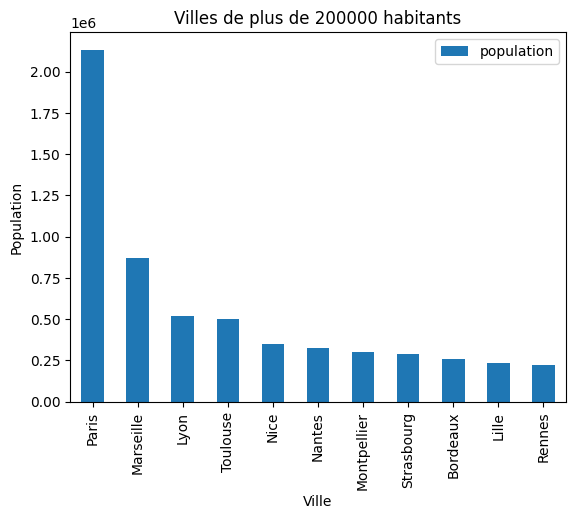

In [ ]:
# Définir un seuil de population
min_treshold = 200_000

# Créer un graphique à barres pour les villes avec une population supérieure au seuil
df[df.population >= min_treshold].plot(
    kind="bar",
    x="nom_standard",
    y="population",
    title=f"Villes de plus de {min_treshold} habitants",
    xlabel="Ville",
    ylabel="Population",
)

# NB: f"{}": permet d'insérer une variable dans une chaîne de caractères. C'est ce que l'on appelle une
# f-string.

<Axes: title={'center': 'Répartition de la population des communes'}, xlabel='Population', ylabel='Nombre de communes'>

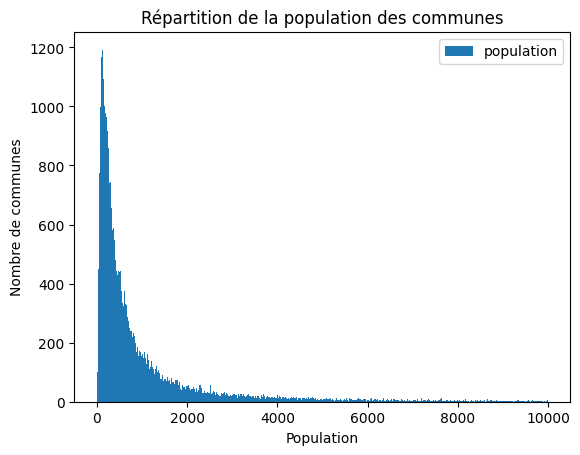

In [ ]:
# Créer un histogramme pour les villes avec une population inférieure ou égale à 10 000
df[df.population <= 10_000].plot(
    kind="hist",
    y="population",
    bins=500,
    title="Répartition de la population des communes",
    xlabel="Population",
    ylabel="Nombre de communes",
)

### Exercice 🐍

L'objectif de cet exercice est de vous familiariser avec les techniques de visualisation de données en utilisant Matplotlib. Vous apprendrez à manipuler un DataFrame Pandas pour créer des graphiques informatifs et interactifs. Vous allez représenter les villes françaises sur une carte, en utilisant différentes caractéristiques pour enrichir la visualisation.

### Objectifs
- Comprendre comment utiliser Matplotlib pour visualiser des données.
- Apprendre à créer des graphiques de dispersion (scatter plots) pour représenter des données géographiques.
- Utiliser des couleurs et des tailles de points pour représenter différentes caractéristiques des villes.
- Apprendre à filtrer les données pour se concentrer sur des sous-ensembles spécifiques.

##### I - Affichez la carte de France des villes avec matplotlib représentée par un nuage de points.
Sachant que les colonnes d'un tableau Pandas peuvent être passées directement en paramètres des fonctions de matplotlib:

1. Afficher un point par ville (latitude_mairie et longitude_mairie), avec une taille proportionnelle à la population (population) et avec une couleur liée à l'altitude (altitude_maximale)

### Si vous avez déjà fini:

##### II - Affichez la carte de France métropolitaine représentée par un nuage de points.

1. Selectionnez uniquement les départements de France métropolitaine (code département < 100)

Répétez les mêmes graphiques, attention au type de dep_code

Vous pourriez avoir besoin de relire le fichier des villes en précisant le type de la colonne département ou de modifier la colonne en changeant son type

2. Ajouter sur le graphique en rouge les villes ayant plus de 500 000 habitants

In [ ]:
# A vous de jouer !

### Exercice 🐍 de cartographie
La librairie folium permet d'afficher des fonds de cartes à la GoogleMap/OpenStreetMap

La librairie Nominatim permet quant-à elle de localiser votre position de multiples manières (adresse postale, ip, ...)

1. Créer un jeu de données contenant uniquement les colonnes: nom_standard, latitude_mairie, longitude_mairie, population, grille_densite_texte

2. Centrer la carte sur la moyenne des coordonnées des villes de France

3. Utiliser les colonnes latitude_mairie et longitude_mairie

4. Lister 5 villes au hasard parmis les 10 plus peuplées et 5 villes au hasard parmis les 10 moins peuplées

5. Puis à l'aide de la fonction df.itertuples() afficher un marker par ville avec l'information de la densité de population

In [ ]:
# A vous de jouer !

# Pour aller plus loin

### 6. Fusionner des DataFrames


In [ ]:
cols_ville = [
    "code_insee",
    "nom_standard",
    "dep_code",
    "reg_nom",
]

cols_stats = [
    "code_insee",
    "population",
    "superficie_km2",
    "densite",
    "altitude_minimale",
    "altitude_maximale",
]

In [ ]:
df_ville = df[cols_ville]
df_stats = df[cols_stats]

df_ville.head()

,code_insee,nom_standard,dep_code,reg_nom
0,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes
1,01002,L'Abergement-de-Varey,01,Auvergne-Rhône-Alpes
2,01004,Ambérieu-en-Bugey,01,Auvergne-Rhône-Alpes
3,01005,Ambérieux-en-Dombes,01,Auvergne-Rhône-Alpes
4,01006,Ambléon,01,Auvergne-Rhône-Alpes


In [ ]:
df_stats.head()

,code_insee,population,superficie_km2,densite,altitude_minimale,altitude_maximale
0,01001,832,16,53.0,206.0,272.0
1,01002,267,9,29.0,290.0,748.0
2,01004,14854,24,607.0,237.0,753.0
3,01005,1897,16,118.0,265.0,302.0
4,01006,113,6,19.0,330.0,940.0


De la même manière qu'en SQL, on peut fusionner des DataFrames en utilisant la méthode `merge()`. Cette méthode permet de combiner deux DataFrames en fonction d'une ou plusieurs colonnes communes. On se base sur la notion de ``clef`` (ou clé primaire) pour effectuer la jointure.

A la différence de SQL, il n'est pas nécessaire de créer une table intermédiaire pour effectuer la jointure. Pandas gère cela en interne.

On optimisera les performances si la clef primaire est un index.

In [ ]:
import time

start_time = time.time()
# Créer un DataFrame avec les villes et leurs statistiques
df_merged = df_ville.merge(
    df_stats,
    how="inner",  # inner join
    left_on="code_insee",  # clé de jointure dans le DataFrame de gauche
    right_on="code_insee",  # clé de jointure dans le DataFrame de droite
)
print("Temps d'exécution:", time.time() - start_time, "s.")
df_merged.head()

Temps d'exécution: 0.029431819915771484 s.


,code_insee,nom_standard,dep_code,reg_nom,population,superficie_km2,densite,altitude_minimale,altitude_maximale
0,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,832,16,53.0,206.0,272.0
1,01002,L'Abergement-de-Varey,01,Auvergne-Rhône-Alpes,267,9,29.0,290.0,748.0
2,01004,Ambérieu-en-Bugey,01,Auvergne-Rhône-Alpes,14854,24,607.0,237.0,753.0
3,01005,Ambérieux-en-Dombes,01,Auvergne-Rhône-Alpes,1897,16,118.0,265.0,302.0
4,01006,Ambléon,01,Auvergne-Rhône-Alpes,113,6,19.0,330.0,940.0


In [ ]:
# Set the index to the code_insee column
df_ville_indexed = df_ville.set_index("code_insee")
df_stats_indexed = df_stats.set_index("code_insee")

# Merge the two DataFrames using the index
start_time = time.time()
df_merged_indexed = df_ville_indexed.join(df_stats_indexed, how="inner")  # inner join
print("Temps d'exécution:", time.time() - start_time, "s.")
df_merged_indexed.head()

Temps d'exécution: 0.01349949836730957 s.


,nom_standard,dep_code,reg_nom,population,superficie_km2,densite,altitude_minimale,altitude_maximale
code_insee,,,,,,,,
01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes,832,16,53.0,206.0,272.0
01002,L'Abergement-de-Varey,01,Auvergne-Rhône-Alpes,267,9,29.0,290.0,748.0
01004,Ambérieu-en-Bugey,01,Auvergne-Rhône-Alpes,14854,24,607.0,237.0,753.0
01005,Ambérieux-en-Dombes,01,Auvergne-Rhône-Alpes,1897,16,118.0,265.0,302.0
01006,Ambléon,01,Auvergne-Rhône-Alpes,113,6,19.0,330.0,940.0


In [ ]:
# On peut aussi concaténer les DataFrames
df_ville_1 = df_ville.iloc[:1000, :]
df_ville_2 = df_ville.iloc[1000:, :]

In [ ]:
print(df_ville_1.shape)
df_ville_1.head()

(1000, 4)


,code_insee,nom_standard,dep_code,reg_nom
0,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes
1,01002,L'Abergement-de-Varey,01,Auvergne-Rhône-Alpes
2,01004,Ambérieu-en-Bugey,01,Auvergne-Rhône-Alpes
3,01005,Ambérieux-en-Dombes,01,Auvergne-Rhône-Alpes
4,01006,Ambléon,01,Auvergne-Rhône-Alpes


In [ ]:
print(df_ville_2.shape)
df_ville_2.head()

(33932, 4)


,code_insee,nom_standard,dep_code,reg_nom
1000,02636,Regny,02,Hauts-de-France
1001,02637,Remaucourt,02,Hauts-de-France
1002,02638,Remies,02,Hauts-de-France
1003,02639,Remigny,02,Hauts-de-France
1004,02640,Renansart,02,Hauts-de-France


In [ ]:
df_ville = pd.concat(
    [df_ville_1, df_ville_2],  # liste des DataFrames à concaténer
    axis=0,  # 0 pour concaténer par lignes, 1 pour concaténer par colonnes
    ignore_index=True,  # réinitialiser l'index
)

print(df_ville.shape)
df_ville.head()

(34932, 4)


,code_insee,nom_standard,dep_code,reg_nom
0,01001,L'Abergement-Clémenciat,01,Auvergne-Rhône-Alpes
1,01002,L'Abergement-de-Varey,01,Auvergne-Rhône-Alpes
2,01004,Ambérieu-en-Bugey,01,Auvergne-Rhône-Alpes
3,01005,Ambérieux-en-Dombes,01,Auvergne-Rhône-Alpes
4,01006,Ambléon,01,Auvergne-Rhône-Alpes


### 7. Utilisation de fonctions avancées


In [93]:
df["population_millions"] = df["population"].apply(lambda x: x / 1_000_000)

df[["nom_standard", "population", "population_millions"]].sort_values(
    by="population", ascending=False
).head()

,nom_standard,population,population_millions
29243,Paris,2133111,2.133111
4342,Marseille,873076,0.873076
27081,Lyon,522250,0.522250
11793,Toulouse,504078,0.504078
1954,Nice,348085,0.348085


In [94]:
def calcul_densite(population: int, superficie: float) -> float:
    """
    Calculer la densité de population d'une commune.

    :param population: Population de la commune
    :param superficie: Superficie de la commune en km²
    :return: Densité de population en habitants par km²
    """
    return population / superficie if superficie > 0 else 0


df["densite_calc"] = df.apply(
    lambda row: calcul_densite(
        population=row["population"], superficie=row["superficie_km2"]
    ),
    axis=1,
)

df[["nom_standard", "population", "superficie_km2", "densite_calc"]].head()

,nom_standard,population,superficie_km2,densite_calc
0,L'Abergement-Clémenciat,832,16,52.000000
1,L'Abergement-de-Varey,267,9,29.666667
2,Ambérieu-en-Bugey,14854,24,618.916667
3,Ambérieux-en-Dombes,1897,16,118.562500
4,Ambléon,113,6,18.833333


In [96]:
df_sorted = df.sort_values(by="population", ascending=False)
df_sorted.head()

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve,Pays,population_millions,densite_calc
29243,Paris,75056,Paris,à Paris,de Paris,paris,PARIS,COM,commune,11,...,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Parisien,https://fr.wikipedia.org/wiki/fr:Paris,https://villedereve.fr/ville/75056-paris,France,2.133111,20315.342857
4342,Marseille,13055,Marseille,à Marseille,de Marseille,marseille,MARSEILLE,COM,commune,93,...,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Marseillais,https://fr.wikipedia.org/wiki/fr:Marseille,https://villedereve.fr/ville/13055-marseille,France,0.873076,3622.721992
27081,Lyon,69123,Lyon,à Lyon,de Lyon,lyon,LYON,COM,commune,84,...,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,"Lyonnais, Lyonnaise",https://fr.wikipedia.org/wiki/fr:Lyon,https://villedereve.fr/ville/69123-lyon,France,0.522250,10880.208333
11793,Toulouse,31555,Toulouse,à Toulouse,de Toulouse,toulouse,TOULOUSE,COM,commune,76,...,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Toulousains,https://fr.wikipedia.org/wiki/fr:Toulouse,https://villedereve.fr/ville/31555-toulouse,France,0.504078,4271.847458
1954,Nice,06088,Nice,à Nice,de Nice,nice,NICE,COM,commune,93,...,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Niçois,https://fr.wikipedia.org/wiki/fr:Nice,https://villedereve.fr/ville/06088-nice,France,0.348085,4703.851351


In [ ]:
df_sorted["nom_court"] = df_sorted["nom_standard"].map(
    {"Paris": "PAR", "Lyon": "LY", "Marseille": "MAR"}
)
df_sorted[["nom_standard", "nom_court"]].head()

,nom_standard,nom_court
29243,Paris,PAR
4342,Marseille,MAR
27081,Lyon,LY
11793,Toulouse,NaN
1954,Nice,NaN


### Skimpy

Skimpy est une bibliothèque Python qui permet d'explorer rapidement des DataFrames Pandas. Elle fournit des résumés statistiques, des visualisations et des informations sur les colonnes, facilitant ainsi l'analyse exploratoire des données.

In [ ]:
df

,nom_standard,code_insee,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,reg_code,...,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve,pays,denivele_metres
29243,Paris,75056,Paris,à Paris,de Paris,paris,PARIS,COM,commune,11,...,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Parisien,https://fr.wikipedia.org/wiki/fr:Paris,https://villedereve.fr/ville/75056-paris,France,103.0
4342,Marseille,13055,Marseille,à Marseille,de Marseille,marseille,MARSEILLE,COM,commune,93,...,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Marseillais,https://fr.wikipedia.org/wiki/fr:Marseille,https://villedereve.fr/ville/13055-marseille,France,652.0
27081,Lyon,69123,Lyon,à Lyon,de Lyon,lyon,LYON,COM,commune,84,...,NaN,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,"Lyonnais, Lyonnaise",https://fr.wikipedia.org/wiki/fr:Lyon,https://villedereve.fr/ville/69123-lyon,France,143.0
11793,Toulouse,31555,Toulouse,à Toulouse,de Toulouse,toulouse,TOULOUSE,COM,commune,76,...,1.432,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Toulousains,https://fr.wikipedia.org/wiki/fr:Toulouse,https://villedereve.fr/ville/31555-toulouse,France,148.0
1954,Nice,06088,Nice,à Nice,de Nice,nice,NICE,COM,commune,93,...,7.238,1,Grands centres urbains,4.0,centres majeurs d'équipements et de services,Niçois,https://fr.wikipedia.org/wiki/fr:Nice,https://villedereve.fr/ville/06088-nice,France,520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20198,Haumont-près-Samogneux,55239,Haumont-près-Samogneux,à Haumont-près-Samogneux,d'Haumont-près-Samogneux,haumont-pres-samogneux,HAUMONT-PRÈS-SAMOGNEUX,COM,commune,44,...,5.369,7,Rural à habitat très dispersé,0.0,communes non pôle,Sachots,https://fr.wikipedia.org/wiki/fr:Haumont-près-...,https://villedereve.fr/ville/55239-haumont-pre...,France,161.0
20118,Cumières-le-Mort-Homme,55139,Cumières-le-Mort-Homme,à Cumières-le-Mort-Homme,de Cumières-le-Mort-Homme,cumieres-le-mort-homme,CUMIÈRES-LE-MORT-HOMME,COM,commune,44,...,5.268,7,Rural à habitat très dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:Cumières-le-M...,https://villedereve.fr/ville/55139-cumieres-le...,France,102.0
20257,Louvemont-Côte-du-Poivre,55307,Louvemont-Côte-du-Poivre,à Louvemont-Côte-du-Poivre,de Louvemont-Côte-du-Poivre,louvemont-cote-du-poivre,LOUVEMONT-CÔTE-DU-POIVRE,COM,commune,44,...,5.402,7,Rural à habitat très dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:Louvemont-Côt...,https://villedereve.fr/ville/55307-louvemont-c...,France,161.0
20043,Bezonvaux,55050,Bezonvaux,à Bezonvaux,de Bezonvaux,bezonvaux,BEZONVAUX,COM,commune,44,...,5.472,7,Rural à habitat très dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:Bezonvaux,https://villedereve.fr/ville/55050-bezonvaux,France,141.0


In [ ]:
df.columns

Index(['nom_standard', 'code_insee', 'nom_sans_pronom', 'nom_a', 'nom_de',
       'nom_sans_accent', 'nom_standard_majuscule', 'typecom', 'typecom_texte',
       'reg_code', 'reg_nom', 'dep_code', 'dep_nom', 'canton_code',
       'canton_nom', 'epci_code', 'epci_nom', 'academie_code', 'academie_nom',
       'code_postal', 'codes_postaux', 'zone_emploi',
       'code_insee_centre_zone_emploi', 'code_unite_urbaine',
       'nom_unite_urbaine', 'taille_unite_urbaine',
       'type_commune_unite_urbaine', 'statut_commune_unite_urbaine',
       'population', 'superficie_hectare', 'superficie_km2', 'densite',
       'altitude_moyenne', 'altitude_minimale', 'altitude_maximale',
       'latitude_mairie', 'longitude_mairie', 'latitude_centre',
       'longitude_centre', 'grille_densite', 'grille_densite_texte',
       'niveau_equipements_services', 'niveau_equipements_services_texte',
       'gentile', 'url_wikipedia', 'url_villedereve', 'pays',
       'denivele_metres'],
      dtype='object')

In [ ]:
from skimpy import skim


# testons sur un sous ensemble de colonnes
cols = [
    "code_insee",
    "nom_standard",
    "population",
    "densite",
    "superficie_km2",
    "latitude_centre",
    "longitude_centre",
]
df_selected = df[cols]

In [ ]:
skim(df_selected)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 34932  │ │ float64     │ 3     │                                                          │
│ │ Number of columns │ 6      │ │ int64       │ 2     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA ┃ NA %            ┃ mean  ┃ sd    ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ population      │  0 │               0 │  1937 │ 14990 │      0 │   197 │   457 │  1164 │ 2133000 │   █    │  │
│ │ densite         │  0 │               0 │ 169.3 │ 752.1 │      0 │    18 │    41 │   100 │   28220 │   █    │  │
│ │ superficie_km2  │  0 │               0 │ 17.63 │ 148.2 │      0 │     6 │    11 │    19 │   18720 │   █    │  │
│ │ latitude_centre │  6 │ 0.0171762281003 │ 46.79 │ 3.588 │ -21.34 │ 45.07 │ 47.35 │ 48.82 │   51.07 │      █ │  │
│ │                 │    │           09172 │       │       │        │       │       │       │         │        │  │
│ │ longitude_centr │  6 │ 0.0171762281003 │ 2.714 │ 4.412 │ -61.78 │ 0.793 │ 2.718 │ 4.918 │   55.75 │     █  │  │
│ │ e               │    │           09172 │       │       │        │       │       │       │         │        │  │
│ └─────────────────┴────┴─────────────────┴───────┴───────┴────────┴───────┴───────┴───────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃              ┃    ┃      ┃          ┃         ┃      ┃        ┃               ┃ words per    ┃             ┃  │
│ ┃ column       ┃ NA ┃ NA % ┃ shortest ┃ longest ┃ min  ┃ max    ┃ chars per row ┃ row          ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ nom_standard │  0 │    0 │ Caumont  │ Cahors  │ Aast │ Œuilly │          11.8 │          1.1 │       37432 │  │
│ └──────────────┴────┴──────┴──────────┴─────────┴──────┴────────┴───────────────┴──────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

### Fireducks

Fireducks est une bibliothèque qui permet d'accélérer considérablement le traitement des DataFrames Pandas en utilisant la puissance de la parallélisation. Elle est conçue pour fonctionner avec des DataFrames de grande taille et peut améliorer les performances des opérations courantes telles que les jointures, les agrégations et les filtrages.

In [ ]:
# avec pandas
filepath = "data/communes-france-2025.csv"

In [ ]:
import pandas as pd
import time

t0 = time.time()
df = pd.read_csv(filepath)
t1 = time.time()
df = df.sort_values("nom_standard")
t2 = time.time()

print("Temps de lecture du fichier CSV:", t1 - t0, "s.")
print("Temps de tri du DataFrame:", t2 - t1, "s.")

Temps de lecture du fichier CSV: 0.3222846984863281 s.
Temps de tri du DataFrame: 0.03502082824707031 s.


/tmp/ipykernel_172019/3654847118.py:5: DtypeWarning: Columns (0,11,13,15,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


In [ ]:
import fireducks.pandas as fd

t0 = time.time()
df = fd.read_csv(filepath)
t1 = time.time()
df = df.sort_values("nom_standard")
t2 = time.time()

print("Temps de lecture du fichier CSV:", t1 - t0, "s.")
print("Temps de tri du DataFrame:", t2 - t1, "s.")

Temps de lecture du fichier CSV: 0.08138132095336914 s.
Temps de tri du DataFrame: 0.00029969215393066406 s.
